In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
import re

warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load tuned model and processed data
print("Loading model and data...")

tuned_model = joblib.load('../src/model_tuned_lightgbm.pkl')

X = pd.read_csv('../data/X_processed.csv')
y = pd.read_csv('../data/y_target.csv').squeeze()

# Clean column names — same fix as modelling notebook
def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X = clean_column_names(X)

# Use a sample for SHAP — computing SHAP values for 300k rows is very slow
# 5,000 rows is standard practice for SHAP analysis
X_sample = X.sample(5000, random_state=42)
y_sample = y[X_sample.index]

print(f"Model loaded: {type(tuned_model).__name__}")
print(f"Full dataset: {X.shape}")
print(f"SHAP sample: {X_sample.shape}")
print(f"Sample default rate: {y_sample.mean() * 100:.2f}%")

Loading model and data...
Model loaded: LGBMClassifier
Full dataset: (307511, 233)
SHAP sample: (5000, 233)
Sample default rate: 8.24%


In [4]:
# Compute SHAP values using TreeExplainer
# TreeExplainer is optimised for tree-based models like LightGBM
print("Computing SHAP values — this will take a few minutes...")

explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_sample)

# LightGBM returns shap values for both classes
# Index 1 = SHAP values for the default class (TARGET = 1)
# This is what we care about
if isinstance(shap_values, list):
    shap_values_default = shap_values[1]
else:
    shap_values_default = shap_values

print(f"SHAP values computed successfully")
print(f"SHAP values shape: {shap_values_default.shape}")
print(f"Features: {X_sample.shape[1]}")
print(f"Samples: {X_sample.shape[0]}")

Computing SHAP values — this will take a few minutes...
SHAP values computed successfully
SHAP values shape: (5000, 233)
Features: 233
Samples: 5000


In [5]:
# Global feature importance — mean absolute SHAP values
shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': np.abs(shap_values_default).mean(axis=0)
}).sort_values('importance', ascending=False)

print("Top 20 most important features:")
print(shap_importance.head(20).to_string(index=False))

Top 20 most important features:
                             feature  importance
                     EXT_SOURCE_MEAN    0.365917
                        EXT_SOURCE_3    0.194652
                           LOAN_TERM    0.121793
                        EXT_SOURCE_2    0.106347
                      EXT_SOURCE_MIN    0.095095
                        EXT_SOURCE_1    0.090431
                       DAYS_EMPLOYED    0.070506
       NAME_CONTRACT_TYPE_Cash_loans    0.068287
                           AGE_YEARS    0.058820
                          DAYS_BIRTH    0.058534
                    EMPLOYMENT_YEARS    0.054871
                       CODE_GENDER_F    0.054019
NAME_EDUCATION_TYPE_Higher_education    0.050638
                     DAYS_ID_PUBLISH    0.050564
                         OWN_CAR_AGE    0.044942
                ANNUITY_INCOME_RATIO    0.042802
                   DAYS_REGISTRATION    0.041791
                         AMT_ANNUITY    0.041328
                          AMT_CREDIT 

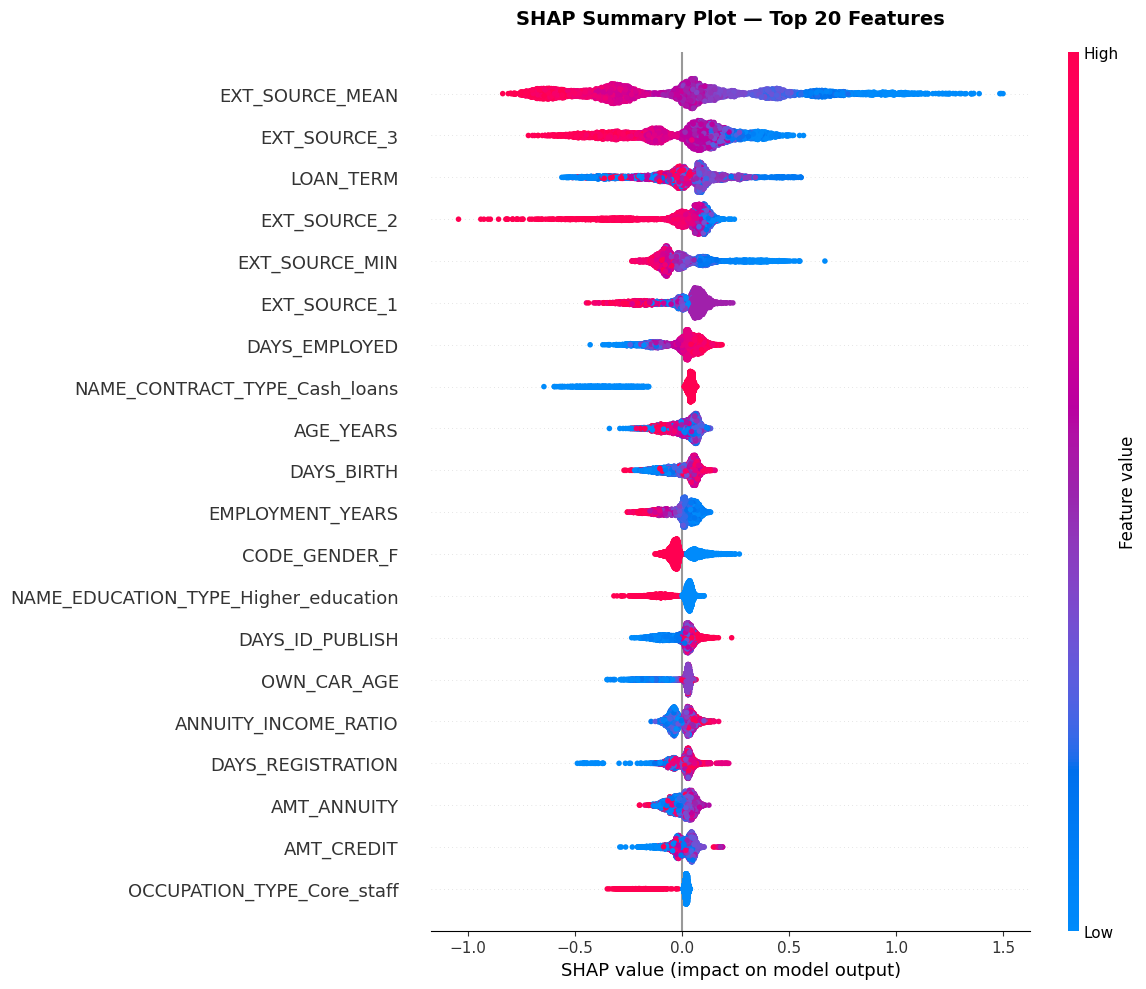

SHAP summary plot saved.


In [7]:
# SHAP summary plot — shows direction and magnitude of feature impact
plt.figure(figsize=(12, 10))

shap.summary_plot(
    shap_values_default,
    X_sample,
    max_display=20,
    show=False,
    plot_size=None
)

plt.title('SHAP Summary Plot — Top 20 Features', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP summary plot saved.")

In [9]:
# Find better examples — applicants where the model is correct
# Get predictions for all sample applicants
y_prob_sample = tuned_model.predict_proba(X_sample)[:, 1]

# Build a results dataframe
results = pd.DataFrame({
    'actual': y_sample.values,
    'prob_default': y_prob_sample,
    'index_pos': range(len(X_sample))
}, index=X_sample.index)

# Find a correctly predicted high-risk applicant
# Actual defaulter with high predicted probability
correct_defaulters = results[
    (results['actual'] == 1) & 
    (results['prob_default'] > 0.5)
].sort_values('prob_default', ascending=False)

# Find a correctly predicted low-risk applicant  
# Actual non-defaulter with low predicted probability
correct_non_defaulters = results[
    (results['actual'] == 0) & 
    (results['prob_default'] < 0.2)
].sort_values('prob_default', ascending=True)

print(f"Correctly predicted high-risk applicants: {len(correct_defaulters)}")
print(f"Correctly predicted low-risk applicants: {len(correct_non_defaulters)}")

if len(correct_defaulters) > 0:
    best_defaulter = correct_defaulters.iloc[0]
    print(f"\nBest high-risk example:")
    print(f"  Actual: DEFAULT | Predicted probability: {best_defaulter['prob_default']:.4f}")

if len(correct_non_defaulters) > 0:
    best_non_defaulter = correct_non_defaulters.iloc[0]
    print(f"\nBest low-risk example:")
    print(f"  Actual: NO DEFAULT | Predicted probability: {best_non_defaulter['prob_default']:.4f}")

Correctly predicted high-risk applicants: 276
Correctly predicted low-risk applicants: 1163

Best high-risk example:
  Actual: DEFAULT | Predicted probability: 0.9078

Best low-risk example:
  Actual: NO DEFAULT | Predicted probability: 0.0160


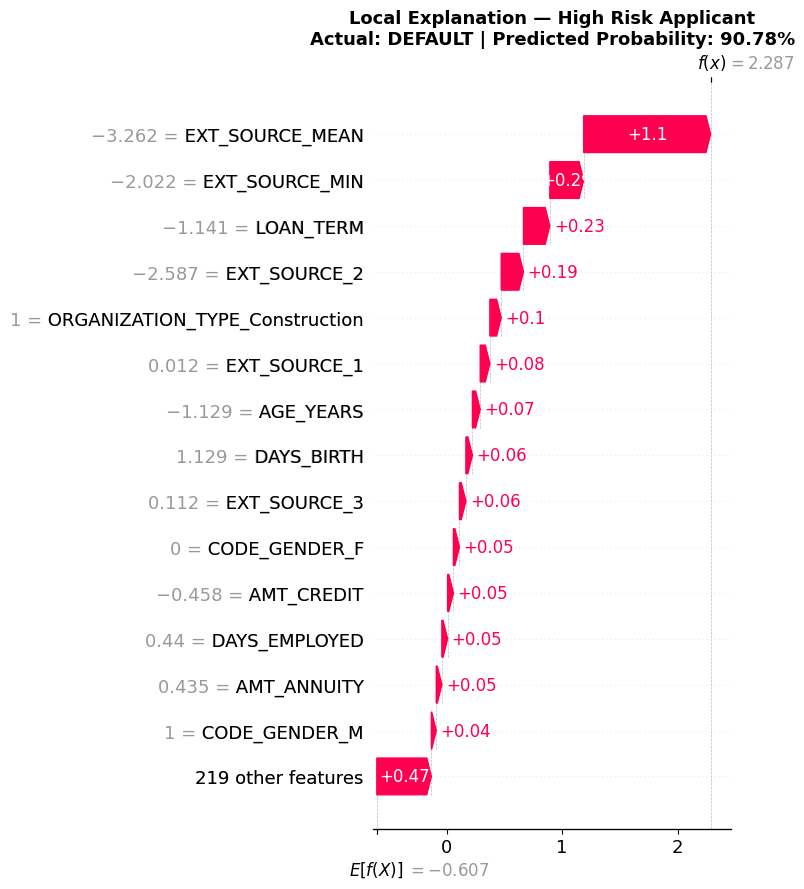

High risk applicant explanation saved.


In [10]:
# Get positions in X_sample
defaulter_pos = int(best_defaulter['index_pos'])
non_defaulter_pos = int(best_non_defaulter['index_pos'])

# Base value
base_value = explainer.expected_value[1] if isinstance(
    explainer.expected_value, list) else explainer.expected_value

# Waterfall plot — high risk applicant
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_default[defaulter_pos],
        base_values=base_value,
        data=X_sample.iloc[defaulter_pos],
        feature_names=X_sample.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title(
    f'Local Explanation — High Risk Applicant\n'
    f'Actual: DEFAULT | Predicted Probability: {best_defaulter["prob_default"]:.2%}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/shap_local_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("High risk applicant explanation saved.")

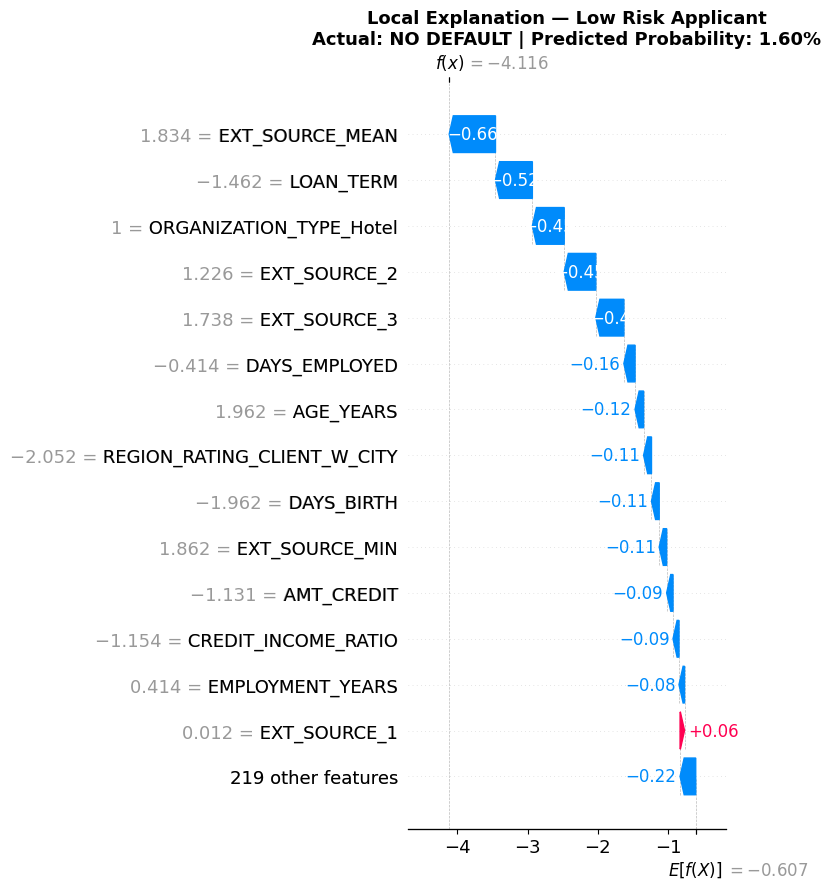

Low risk applicant explanation saved.


In [11]:
# Waterfall plot — low risk applicant
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_default[non_defaulter_pos],
        base_values=base_value,
        data=X_sample.iloc[non_defaulter_pos],
        feature_names=X_sample.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title(
    f'Local Explanation — Low Risk Applicant\n'
    f'Actual: NO DEFAULT | Predicted Probability: {best_non_defaulter["prob_default"]:.2%}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/shap_local_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("Low risk applicant explanation saved.")

=== ERROR ANALYSIS ===
outcome
True Negative (correctly cleared applicant)      3286
False Positive (wrongly flagged as defaulter)    1302
True Positive (correctly caught defaulter)        276
False Negative (missed defaulter)                 136
Name: count, dtype: int64

Total applicants in sample: 5,000

False Negative rate (missed defaulters): 33.0%
False Positive rate (wrongly flagged): 28.4%


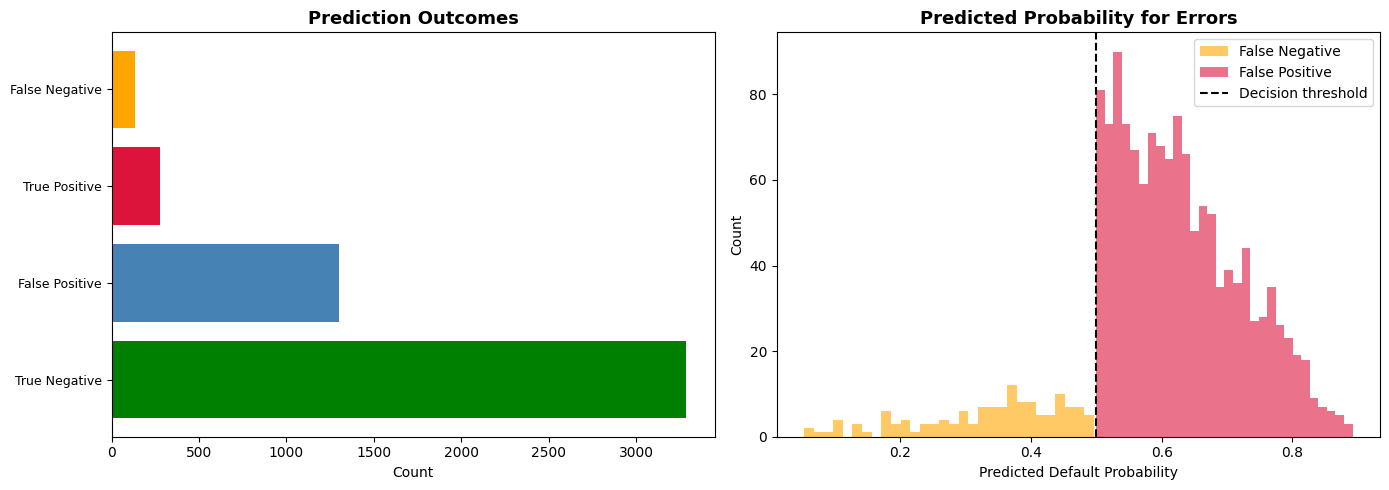


Error analysis saved.


In [13]:
# Error analysis — where is the model getting things wrong?
y_prob_sample = tuned_model.predict_proba(X_sample)[:, 1]
y_pred_sample = (y_prob_sample >= 0.5).astype(int)

results['predicted'] = y_pred_sample
results['prob_default'] = y_prob_sample

# Classify each prediction
def classify_prediction(row):
    if row['actual'] == 1 and row['predicted'] == 1:
        return 'True Positive (correctly caught defaulter)'
    elif row['actual'] == 0 and row['predicted'] == 0:
        return 'True Negative (correctly cleared applicant)'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'False Positive (wrongly flagged as defaulter)'
    else:
        return 'False Negative (missed defaulter)'

results['outcome'] = results.apply(classify_prediction, axis=1)

print("=== ERROR ANALYSIS ===")
print(results['outcome'].value_counts())
print(f"\nTotal applicants in sample: {len(results):,}")
print(f"\nFalse Negative rate (missed defaulters): "
      f"{(results['outcome'].str.contains('False Negative').sum() / results['actual'].sum() * 100):.1f}%")
print(f"False Positive rate (wrongly flagged): "
      f"{(results['outcome'].str.contains('False Positive').sum() / (results['actual'] == 0).sum() * 100):.1f}%")

# Plot error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Outcome counts
outcome_counts = results['outcome'].value_counts()
colors = ['green', 'steelblue', 'crimson', 'orange']
axes[0].barh(range(len(outcome_counts)), outcome_counts.values, color=colors)
axes[0].set_yticks(range(len(outcome_counts)))
axes[0].set_yticklabels([o.split('(')[0].strip() for o in outcome_counts.index], fontsize=9)
axes[0].set_title('Prediction Outcomes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

# Probability distribution by error type
for outcome, color in [
    ('False Negative', 'orange'),
    ('False Positive', 'crimson')
]:
    subset = results[results['outcome'].str.contains(outcome)]['prob_default']
    if len(subset) > 0:
        axes[1].hist(subset, bins=30, alpha=0.6, label=outcome, color=color)

axes[1].set_title('Predicted Probability for Errors', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Default Probability')
axes[1].set_ylabel('Count')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/error_analysis.png', dpi=150)
plt.show()

print("\nError analysis saved.")

In [14]:
import joblib
import os

# Save SHAP values for use in the generative AI step
os.makedirs('../src', exist_ok=True)

joblib.dump(explainer, '../src/shap_explainer.pkl')
joblib.dump(shap_values_default, '../src/shap_values.pkl')
joblib.dump(shap_importance, '../src/shap_importance.pkl')

print("SHAP explainer saved to src/shap_explainer.pkl")
print("SHAP values saved to src/shap_values.pkl")
print("Feature importance saved to src/shap_importance.pkl")

print("\n=== STEP 5 COMPLETE ===")
print("SHAP feature importance:     DONE")
print("SHAP summary plot:           DONE")
print("Local explanation — high risk: DONE")
print("Local explanation — low risk:  DONE")
print("Error analysis:              DONE")
print("\nReports saved:")
reports = [
    'shap_summary_plot.png',
    'shap_local_high_risk.png',
    'shap_local_low_risk.png',
    'error_analysis.png'
]
for r in reports:
    print(f"  reports/{r}")

SHAP explainer saved to src/shap_explainer.pkl
SHAP values saved to src/shap_values.pkl
Feature importance saved to src/shap_importance.pkl

=== STEP 5 COMPLETE ===
SHAP feature importance:     DONE
SHAP summary plot:           DONE
Local explanation — high risk: DONE
Local explanation — low risk:  DONE
Error analysis:              DONE

Reports saved:
  reports/shap_summary_plot.png
  reports/shap_local_high_risk.png
  reports/shap_local_low_risk.png
  reports/error_analysis.png
